In [2]:
#Big Data Analysis using PySpark

#Netflix Movies and TV Shows Dataset

#Intern Name:Neha Gangiti

#Domain:Data Analytics Internshipfrom pyspark.sql import SparkSession
import matplotlib.pyplot as plt

In [3]:
spark = SparkSession.builder \
    .appName("Netflix Analysis") \
    .getOrCreate()

26/07/13 21:22:26 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [5]:
df = spark.read.csv(
    "/Users/gangitineha/Desktop/netflix_titles.csv",
    header=True,
    inferSchema=True
)

In [6]:
df.show(5)

+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|        date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|                NULL|United States|September 25, 2021|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|           NULL|Ama Qamata, Khosi...| South Africa|September 24, 2021|        2021| TV-MA|2 Seasons|International TV ...|After crossing pa...|
|     s3|TV Show|           Ganglands|Julien Leclercq|Sami Bouajila, Tr...|         NULL|Septem

In [7]:
df.printSchema()

root
 |-- show_id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- director: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- country: string (nullable = true)
 |-- date_added: string (nullable = true)
 |-- release_year: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- listed_in: string (nullable = true)
 |-- description: string (nullable = true)



In [8]:
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

Total Rows: 8809
Total Columns: 12


In [9]:
from pyspark.sql.functions import col, sum, when

df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
]).show()

+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|show_id|type|title|director|cast|country|date_added|release_year|rating|duration|listed_in|description|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+
|      0|   1|    2|    2636| 826|    832|        13|           2|     6|       5|        3|          3|
+-------+----+-----+--------+----+-------+----------+------------+------+--------+---------+-----------+



In [10]:
clean_df = df.dropna()

In [11]:
print("Rows before cleaning:", df.count())
print("Rows after cleaning :", clean_df.count())

Rows before cleaning: 8809
Rows after cleaning : 5332


In [12]:
movies_tv = clean_df.groupBy("type").count()

movies_tv.show()

+-------+-----+
|   type|count|
+-------+-----+
|TV Show|  147|
|  Movie| 5185|
+-------+-----+



In [ ]:
# Insight 1: Movies vs TV Shows
#The analysis reveals that Netflix hosts a significantly higher number of Movies than TV Shows. This indicates that the platform primarily focuses on movie content while also maintaining a diverse collection of television series.

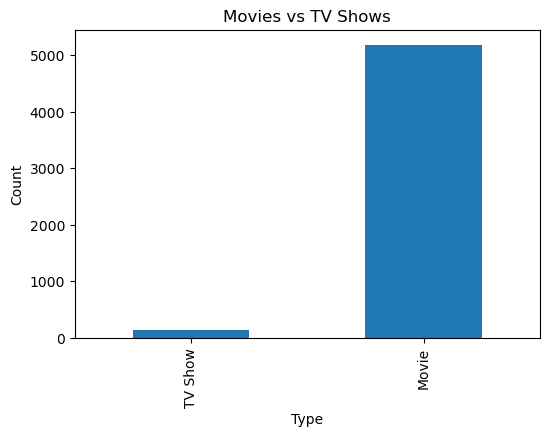

In [13]:
movies_tv_pd = movies_tv.toPandas()

movies_tv_pd.plot(
    kind="bar",
    x="type",
    y="count",
    legend=False,
    figsize=(6,4)
)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [14]:
country_count = df.groupBy("country").count()

country_count = country_count.orderBy("count", ascending=False)

country_count.show(10)

+--------------+-----+
|       country|count|
+--------------+-----+
| United States| 2805|
|         India|  972|
|          NULL|  832|
|United Kingdom|  419|
|         Japan|  245|
|   South Korea|  199|
|        Canada|  181|
|         Spain|  145|
|        France|  123|
|        Mexico|  110|
+--------------+-----+
only showing top 10 rows


In [16]:
country_count = df.filter(df.country.isNotNull()) \
                  .groupBy("country") \
                  .count() \
                  .orderBy("count", ascending=False)

country_count.show(10)

+--------------+-----+
|       country|count|
+--------------+-----+
| United States| 2805|
|         India|  972|
|United Kingdom|  419|
|         Japan|  245|
|   South Korea|  199|
|        Canada|  181|
|         Spain|  145|
|        France|  123|
|        Mexico|  110|
|         Egypt|  106|
+--------------+-----+
only showing top 10 rows


In [ ]:
# Insight 2: Top 10 Countries
#The United States contributes the highest number of titles on Netflix, followed by countries such as India and the United Kingdom. This highlights Netflix's strong presence in major entertainment industries around the world.

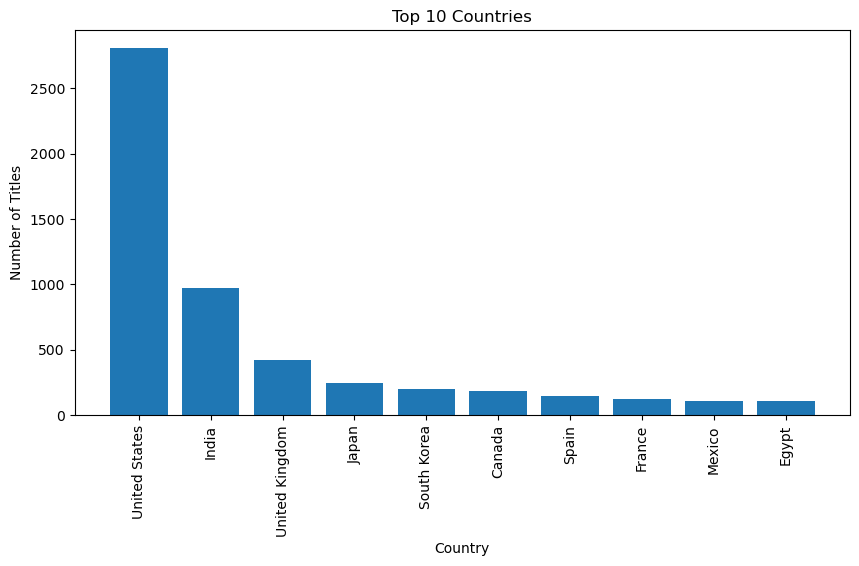

In [17]:
country_pd = country_count.limit(10).toPandas()

plt.figure(figsize=(10,5))
plt.bar(country_pd["country"], country_pd["count"])
plt.xticks(rotation=90)
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
# Insight 3: Content Ratings
#The most common content ratings are TV-MA and TV-14, indicating that a large portion of Netflix's library is designed for mature and teenage audiences.

In [24]:
rating_count = df.filter(df.rating.isNotNull()) \
                 .groupBy("rating") \
                 .count() \
                 .orderBy("count", ascending=False)

rating_count.show()

+-----------------+-----+
|           rating|count|
+-----------------+-----+
|            TV-MA| 3195|
|            TV-14| 2158|
|            TV-PG|  862|
|                R|  796|
|            PG-13|  489|
|            TV-Y7|  334|
|             TV-Y|  307|
|               PG|  286|
|             TV-G|  220|
|               NR|   80|
|                G|   41|
|         TV-Y7-FV|    6|
|               UR|    3|
|            NC-17|    3|
|             2021|    2|
| November 1, 2020|    1|
| Shavidee Trotter|    1|
|    Adriane Lenox|    1|
|    Maury Chaykin|    1|
|             2019|    1|
+-----------------+-----+
only showing top 20 rows


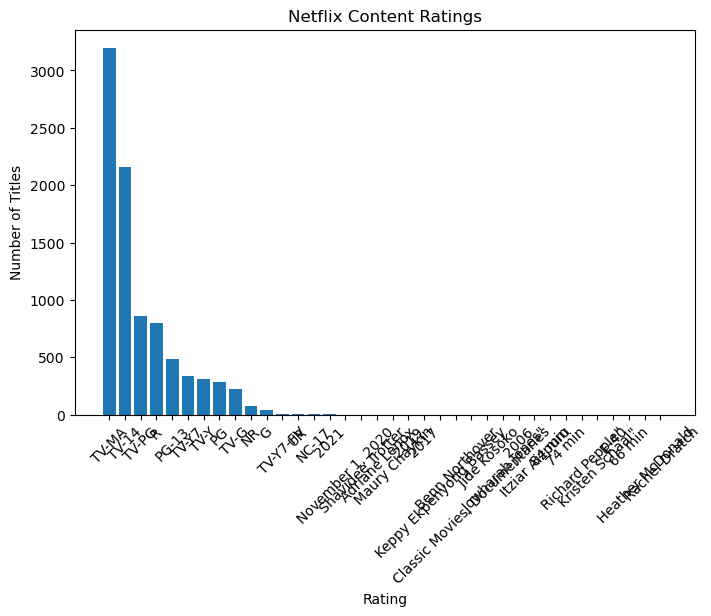

In [25]:
rating_pd = rating_count.toPandas()

plt.figure(figsize=(8,5))
plt.bar(rating_pd["rating"], rating_pd["count"])
plt.xticks(rotation=45)
plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()

In [26]:
# Insight 4: Release Year Trend
#The number of Netflix titles has increased steadily over the years, with a significant rise after 2015. This indicates Netflix's rapid expansion in producing and acquiring content.

In [29]:
year_count = df.filter(df.release_year.isNotNull()) \
               .groupBy("release_year") \
               .count() \
               .orderBy("release_year")

year_count.show()

+-----------------+-----+
|     release_year|count|
+-----------------+-----+
|   Charles Rocket|    1|
|          Dr. Dre|    1|
|   Francis Weddey|    1|
|     Imanol Arias|    1|
|      Jade Eshete|    1|
| Kristen Johnston|    1|
| Marquell Manning|    1|
|       Nick Kroll|    1|
|    Nse Ikpe-Etim|    1|
|       Paul Sambo|    1|
|   Peter Ferriero|    1|
|     Ted Ferguson|    1|
| Álvaro Cervantes|    1|
|             1925|    1|
|             1942|    2|
|             1943|    3|
|             1944|    2|
|             1945|    4|
|             1946|    2|
|             1947|    1|
+-----------------+-----+
only showing top 20 rows


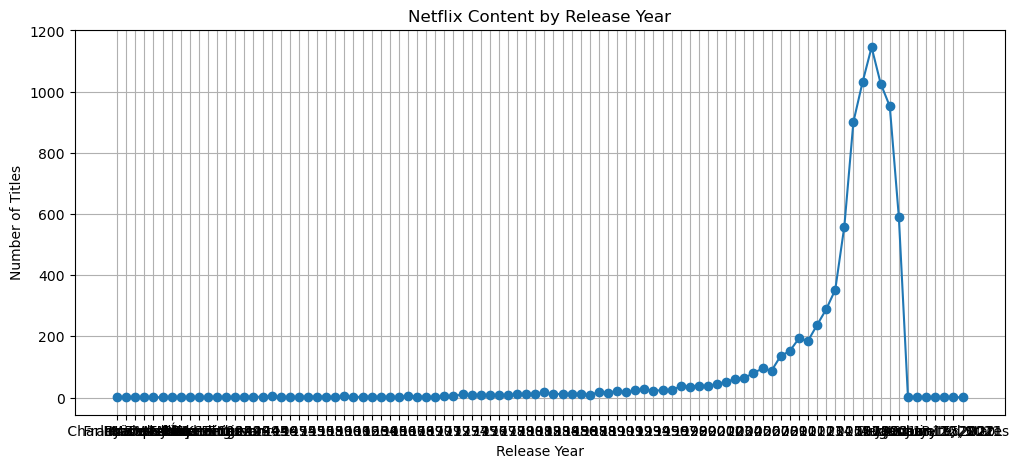

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    year_pd["release_year"],
    year_pd["count"],
    marker='o'
)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

In [ ]:
#Insight 5

#Drama, International Movies, and Comedy are among the most common genres available on Netflix, indicating a diverse content library with strong emphasis on entertainment.

In [18]:
genre_count = df.groupBy("listed_in") \
                .count() \
                .orderBy("count", ascending=False)

genre_count.show(10, truncate=False)

+------------------------------------------------+-----+
|listed_in                                       |count|
+------------------------------------------------+-----+
|Dramas, International Movies                    |361  |
|Documentaries                                   |358  |
|Stand-Up Comedy                                 |334  |
|Comedies, Dramas, International Movies          |273  |
|Dramas, Independent Movies, International Movies|252  |
|Kids' TV                                        |220  |
|Children & Family Movies                        |215  |
|Children & Family Movies, Comedies              |201  |
|Documentaries, International Movies             |186  |
|Dramas, International Movies, Romantic Movies   |180  |
+------------------------------------------------+-----+
only showing top 10 rows


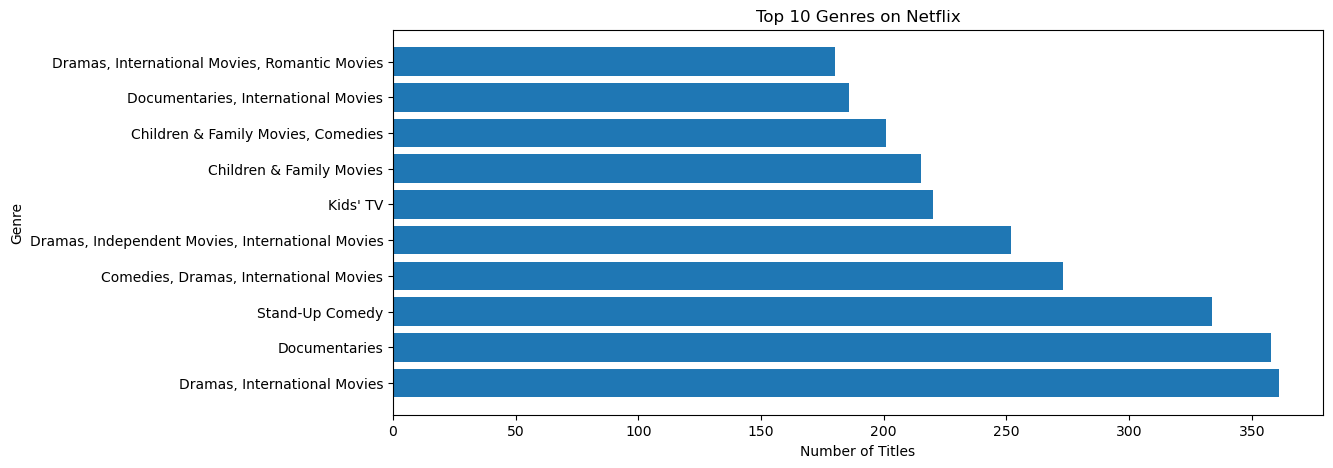

In [19]:
genre_pd = genre_count.limit(10).toPandas()

plt.figure(figsize=(12,5))
plt.barh(genre_pd["listed_in"], genre_pd["count"])
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

In [21]:
#Insight 6
#A few directors have contributed multiple titles to Netflix, while most directors appear only once or twice, indicating a wide variety of creators on the platform.

In [22]:
director_count = df.filter(df.director.isNotNull()) \
                   .groupBy("director") \
                   .count() \
                   .orderBy("count", ascending=False)

director_count.show(10, truncate=False)

+----------------------+-----+
|director              |count|
+----------------------+-----+
|Rajiv Chilaka         |19   |
|Raúl Campos, Jan Suter|18   |
|Marcus Raboy          |16   |
|Suhas Kadav           |16   |
|Jay Karas             |14   |
|Cathy Garcia-Molina   |13   |
|Youssef Chahine       |12   |
|Martin Scorsese       |12   |
|Jay Chapman           |12   |
|Steven Spielberg      |11   |
+----------------------+-----+
only showing top 10 rows


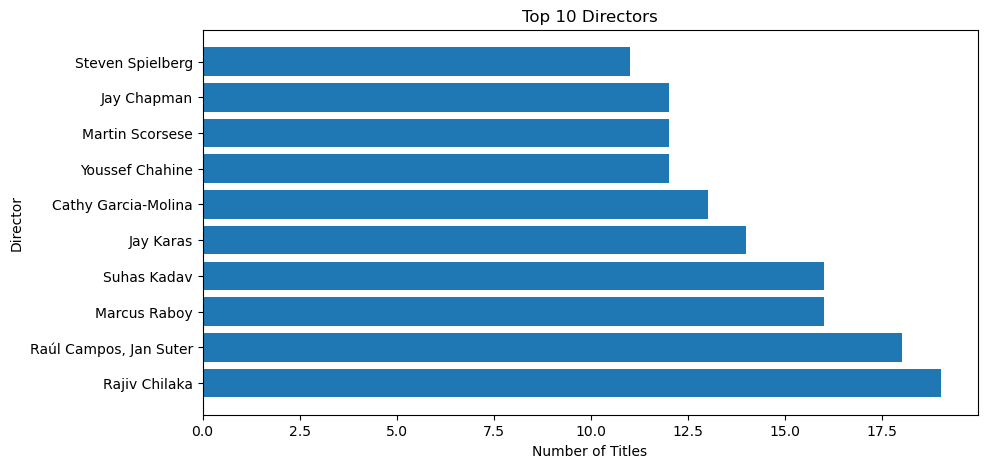

In [23]:
director_pd = director_count.limit(10).toPandas()

plt.figure(figsize=(10,5))
plt.barh(director_pd["director"], director_pd["count"])
plt.title("Top 10 Directors")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

In [34]:
# Conclusion
#This project successfully analyzed the Netflix Movies and TV Shows dataset using PySpark. Data preprocessing and exploratory analysis were performed to understand content distribution, country-wise availability, ratings, release trends, genres, and directors. The analysis demonstrates how PySpark efficiently processes large datasets and helps generate valuable business insights through data visualization.